In [22]:
import os
import json
import torch
import pandas as pd
from pathlib import Path
from PIL import Image

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

path = Path.cwd().parent / "data/raw/sprint_ai_project1_data"
train_path = path / "train_images"
test_path = path / "test_images"
train_annot_path = path / "train_annotations"

print(f"Train images path: {train_path}")
print(f"Test images path: {test_path}")
print(f"Train annotations path: {train_annot_path}")

Using device: mps
Train images path: /Users/codeit/dev/pill-detection-ai/data/raw/sprint_ai_project1_data/train_images
Test images path: /Users/codeit/dev/pill-detection-ai/data/raw/sprint_ai_project1_data/test_images
Train annotations path: /Users/codeit/dev/pill-detection-ai/data/raw/sprint_ai_project1_data/train_annotations


## 파일 수 확인

In [2]:
train_image_files = sorted(train_path.glob('*.png'))
test_image_files = sorted(test_path.glob('*.png'))
train_annotation_files = sorted(train_annot_path.glob('**/*.json'))

# 이미지 장수 확인
print(f"train 이미지 파일 수: {len(train_image_files)}")
print(f"test 이미지 파일 수: {len(test_image_files)}")
print(f"train annotation 파일 수: {len(train_annotation_files)}")

train 이미지 파일 수: 232
test 이미지 파일 수: 842
train annotation 파일 수: 763


## 이미지 사이즈 확인

In [3]:
def get_image_sizes(image_files):
    image_sizes = {}
    for image_file in image_files:
        with Image.open(image_file) as im:
            image_sizes[im.size] = image_sizes.get(im.size, 0) + 1
    return image_sizes

train_image_sizes = get_image_sizes(train_image_files)
print(f"train 이미지 크기: {train_image_sizes}")
test_image_sizes = get_image_sizes(test_image_files)
print(f"test 이미지 크기: {test_image_sizes}")


train 이미지 크기: {(976, 1280): 232}
test 이미지 크기: {(976, 1280): 842}


## annotation을 DataFrame으로 저장 

In [ ]:
def build_annotation_df(annot_dir: Path) -> tuple[pd.DataFrame, dict]:
    """annot_dir 아래 모든 json(=알약 1개 annotation)을 행 1개로 하는 DataFrame 생성."""
    cat_id_to_name = {}
    rows = []
    for jp in sorted(annot_dir.rglob("*.json")):
        with open(jp, encoding="utf-8") as f:
            d = json.load(f)
        if not d.get("images") or not d.get("annotations"):
            continue
        img = d["images"][0]
        cat_id_to_name.update({cat["id"]: cat["name"] for cat in d.get("categories", [])})
        for ann in d["annotations"]:
            x, y, w, h = ann["bbox"]
            rows.append({
                "file_name": img["file_name"],
                "category_id": ann["category_id"],
                "category_name": cat_id_to_name.get(ann["category_id"], "unknown"),
                "bbox_x": x,
                "bbox_y": y,
                "bbox_w": w,
                "bbox_h": h,
                "area": ann["area"],
            })
    return pd.DataFrame(rows), cat_id_to_name


ann_df, category_map = build_annotation_df(train_annot_path)
print(f"annotation 행 수: {len(ann_df)}")
print(f"카테고리 맵: {category_map}")
ann_df.head()

annotation 행 수: 763
카테고리 맵: {1900: '보령부스파정 5mg', 16548: '가바토파정 100mg', 19607: '스토가정 10mg', 29451: '레일라정', 33009: '신바로정', 21771: '라비에트정 20mg', 27926: '울트라셋이알서방정', 24850: '놀텍정 10mg', 29345: '비모보정 500/20mg', 16551: '동아가바펜틴정 800mg', 33208: '에스원엠프정 20mg', 2483: '뮤테란캡슐 100mg', 3743: '알드린정', 12778: '다보타민큐정 10mg/병', 13395: '써스펜8시간이알서방정 650mg', 12081: '리렉스펜정 300mg/PTP', 25438: '큐시드정 31.5mg/PTP', 19552: '트루비타정 60mg/병', 22362: '맥시부펜이알정 300mg', 3351: '일양하이트린정 2mg', 3832: '뉴로메드정(옥시라세탐)', 16232: '리피토정 20mg', 16262: '크레스토정 20mg', 16688: '오마코연질캡슐(오메가-3-산에틸에스테르90)', 20238: '플라빅스정 75mg', 21325: '아토르바정 10mg', 22074: '리피로우정 20mg', 29667: '리바로정 4mg', 35206: '아토젯정 10/40mg', 36637: '로수젯정10/5밀리그램', 38162: '로수바미브정 10/20mg', 13900: '에빅사정(메만틴염산염)(비매품)', 18357: '종근당글리아티린연질캡슐(콜린알포세레이트)\xa0', 19232: '콜리네이트연질캡슐 400mg', 20014: '마도파정', 31863: '아질렉트정(라사길린메실산염)', 32310: '글리아타민연질캡슐', 33880: '글리틴정(콜린알포세레이트)', 41768: '카발린캡슐 25mg', 18147: '리리카캡슐 150mg', 3483: '기넥신에프정(은행엽엑스)(수출용)', 20877: '엑스포지정 5/160mg', 30308: '트라젠타듀오정 2.5

,file_name,category_id,category_name,bbox_x,bbox_y,bbox_w,bbox_h,area
0,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,1900,보령부스파정 5mg,644,845,189,190,35910
1,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,1900,보령부스파정 5mg,148,241,181,181,32761
2,K-001900-016548-019607-029451_0_2_0_2_90_000_2...,1900,보령부스파정 5mg,167,248,184,182,33488
3,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,16548,가바토파정 100mg,144,799,239,239,57121
4,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,16548,가바토파정 100mg,578,222,233,226,52658


## 이미지당 annotation(bbox) 개수 확인

In [28]:
print(f"annotaion 개수 별 이미지 수")
print(ann_df["file_name"].value_counts().value_counts())

annotaion 개수 별 이미지 수
count
3    151
4     74
2      7
Name: count, dtype: int64


## annotation이 없는 이미지가 있는 지 확인

In [30]:
no_annotation_images = []
for img_file in train_image_files:
    if img_file.name not in ann_df["file_name"].values:
        no_annotation_images.append(img_file)

print(f"annotation 없는 이미지 수: {len(no_annotation_images)}")

annotation 없는 이미지 수: 0


## 샘플 이미지, 어노테이션 확인해보기

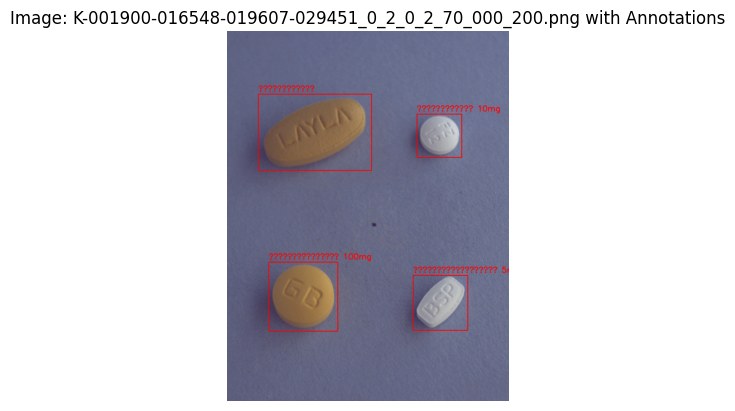

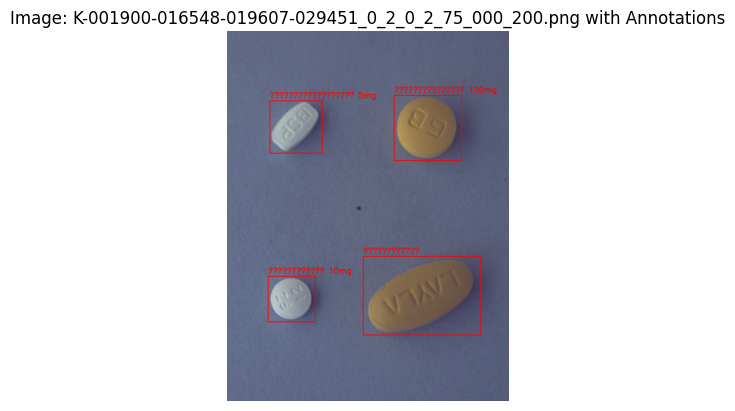

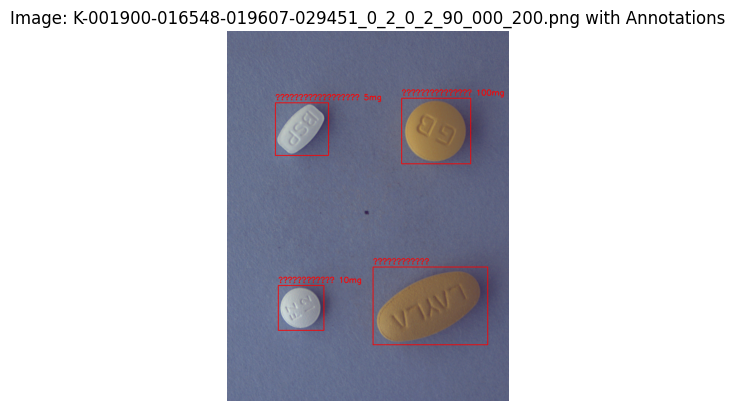

In [35]:
import matplotlib.pyplot as plt
import cv2

def show_image_with_annotaions(image_file):
    """이미지와 해당 이미지의 annotation을 시각화."""
    image = cv2.imread(image_file)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # 해당 이미지의 annotation 가져오기
    image_annotaions = ann_df[ann_df["file_name"] == image_file.name]

    # annotation 그리기
    for annotaion in image_annotaions.itertuples():
        x, y, w, h = annotaion.bbox_x, annotaion.bbox_y, annotaion.bbox_w, annotaion.bbox_h
        category_name = annotaion.category_name
        cv2.rectangle(image, (int(x), int(y)), (int(x + w), int(y + h)), (255, 0, 0), 2)
        cv2.putText(image, category_name, (int(x), int(y) - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)

    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Image: {image_file.name} with Annotations")
    plt.show()


for i in range(3):
    show_image_with_annotaions(train_image_files[i])    